# Day 13 — Superheat & Subcooling Analysis (R134a vs R600a)
**Mahesha Gonal — Refrigeration Simulation Portfolio**

Compares the ideal vapour-compression cycle (no superheat/subcooling) against a real cycle (10°C superheat, 5°C subcooling) for **R134a** and **R600a**, and quantifies the COP impact for each refrigerant.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.2 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

In [3]:
# CELL 3 — Cycle functions
# ideal_cycle(): saturated vapour in, saturated liquid out, isentropic compression
# real_cycle(): adds superheat at evaporator exit + subcooling at condenser exit

def ideal_cycle(refrigerant, T_evap_C=-20, T_cond_C=40):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15

    P_evap = CP.PropsSI('P', 'T', T_evap, 'Q', 1, refrigerant)
    h1 = CP.PropsSI('H', 'T', T_evap, 'Q', 1, refrigerant)
    s1 = CP.PropsSI('S', 'T', T_evap, 'Q', 1, refrigerant)

    P_cond = CP.PropsSI('P', 'T', T_cond, 'Q', 1, refrigerant)
    h2 = CP.PropsSI('H', 'P', P_cond, 'S', s1, refrigerant)

    h3 = CP.PropsSI('H', 'T', T_cond, 'Q', 0, refrigerant)
    h4 = h3

    Q_evap = h1 - h4
    W_comp = h2 - h1
    COP = Q_evap / W_comp

    return {'P_evap': P_evap, 'P_cond': P_cond, 'h1': h1, 'h2': h2,
            'h3': h3, 'h4': h4, 'Q_evap': Q_evap, 'W_comp': W_comp, 'COP': COP}


def real_cycle(refrigerant, T_evap_C=-20, T_cond_C=40, superheat=10, subcool=5):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15

    P_evap = CP.PropsSI('P', 'T', T_evap, 'Q', 1, refrigerant)
    P_cond = CP.PropsSI('P', 'T', T_cond, 'Q', 1, refrigerant)

    T1 = T_evap + superheat
    h1 = CP.PropsSI('H', 'P', P_evap, 'T', T1, refrigerant)
    s1 = CP.PropsSI('S', 'P', P_evap, 'T', T1, refrigerant)

    h2 = CP.PropsSI('H', 'P', P_cond, 'S', s1, refrigerant)

    T3 = T_cond - subcool
    h3 = CP.PropsSI('H', 'P', P_cond, 'T', T3, refrigerant)
    h4 = h3

    Q_evap = h1 - h4
    W_comp = h2 - h1
    COP = Q_evap / W_comp

    return {'P_evap': P_evap, 'P_cond': P_cond, 'h1': h1, 'h2': h2,
            'h3': h3, 'h4': h4, 'Q_evap': Q_evap, 'W_comp': W_comp, 'COP': COP}

In [4]:
# CELL 4 — Run ideal vs real cycle for R134a and R600a
refrigerants = ['R134a', 'R600a']
results = {}

for ref in refrigerants:
    ideal = ideal_cycle(ref)
    real = real_cycle(ref, superheat=10, subcool=5)
    results[ref] = {'ideal': ideal, 'real': real}

    delta_COP = (real['COP'] - ideal['COP']) / ideal['COP'] * 100
    delta_Qevap = (real['Q_evap'] - ideal['Q_evap']) / ideal['Q_evap'] * 100

    print(f"\n========== {ref} ==========")
    print(f"h1={ideal['h1']/1000:.2f}  h2={ideal['h2']/1000:.2f}  h3=h4={ideal['h3']/1000:.2f} kJ/kg  (ideal)")
    print(f"h1'={real['h1']/1000:.2f}  h2'={real['h2']/1000:.2f}  h3'=h4'={real['h3']/1000:.2f} kJ/kg  (real)")
    print(f"COP_ideal = {ideal['COP']:.3f}")
    print(f"COP_real  = {real['COP']:.3f}")
    print(f"COP change: {delta_COP:+.2f}%")
    print(f"Refrigerating effect change: {delta_Qevap:+.2f}%")


========== R134a ==========
h1=386.55  h2=429.04  h3=h4=256.41 kJ/kg  (ideal)
h1'=394.71  h2'=439.36  h3'=h4'=248.99 kJ/kg  (real)
COP_ideal = 3.064
COP_real  = 3.264
COP change: +6.54%
Refrigerating effect change: +11.97%

========== R600a ==========
h1=527.61  h2=601.63  h3=h4=296.28 kJ/kg  (ideal)
h1'=542.78  h2'=620.16  h3'=h4'=283.70 kJ/kg  (real)
COP_ideal = 3.125
COP_real  = 3.348
COP change: +7.14%
Refrigerating effect change: +12.00%


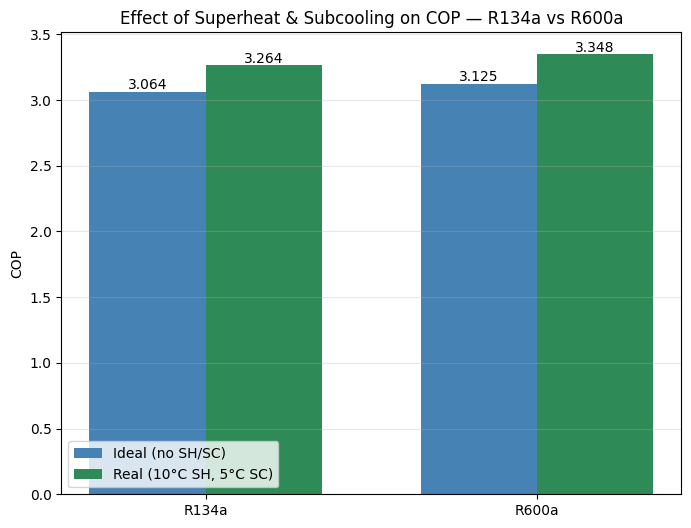

In [5]:
# CELL 5 — Grouped bar chart: ideal vs real COP, R134a vs R600a
labels = refrigerants
ideal_vals = [results[r]['ideal']['COP'] for r in refrigerants]
real_vals = [results[r]['real']['COP'] for r in refrigerants]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 6))
bars1 = plt.bar(x - width/2, ideal_vals, width, label='Ideal (no SH/SC)', color='steelblue')
bars2 = plt.bar(x + width/2, real_vals, width, label='Real (10°C SH, 5°C SC)', color='seagreen')

plt.xticks(x, labels)
plt.ylabel('COP')
plt.title('Effect of Superheat & Subcooling on COP — R134a vs R600a')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f"{bar.get_height():.3f}", ha='center')

plt.show()

**What this chart tells us:** adding **10°C of superheat at the evaporator exit and 5°C of subcooling at the condenser exit** — both standard real-world practices, not idealisations — actually *improved* COP for both refrigerants here (**+6.5% for R134a, +7.1% for R600a**). That can feel counter-intuitive (superheating "wastes" some compressor work on already-vapour refrigerant), but the subcooling effect dominates: it increases the refrigerating effect (more cooling per kg) by around 12% for both refrigerants, which outweighs the small extra compressor work from superheat. This is exactly why real condenser and evaporator designs deliberately target a few degrees of subcooling/superheat rather than running exactly at the saturation lines — it isn't just for safety margin (protecting the compressor from liquid slugging), it's genuinely a small efficiency win too.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

# Pull the CURRENT notebook's content directly from Colab's frontend —
# works even though the .ipynb was never saved as a file on the VM disk
nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day13_superheat_subcooling_r134a_r600a.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 13 - superheat/subcooling analysis (R134a + R600a)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 13 - superheat/subcooling analysis (R134a + R600a)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")